In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import HuberRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

In [6]:
housing_df = pd.read_csv("housing.csv")

housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
print(housing_df.shape)

print(
    housing_df.isna().sum()
)

(20640, 10)
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [10]:
X_real = housing_df.drop(
    columns=["median_house_value"]
)

y_real = housing_df["median_house_value"]

In [11]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.20,
    random_state=42
)

In [12]:
def evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
):

    models = {

        "OLS": LinearRegression(),

        "Ridge": Ridge(alpha=1.0),

        "Huber": HuberRegressor(
            max_iter=1000
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)

In [14]:
np.random.seed(42)

n = 1000

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

error = np.random.normal(0, 1, n)

Y = 3 + 2*X1 + 1.5*X2 - X3 + error

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "Y": Y
})

df.head()
#Step 3. Split the data
X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#80% training, 20% testing.
#Step 4. Create a function to compare models
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Huber": HuberRegressor(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)
results = evaluate_models(
    X_train, X_test, y_train, y_test
)

results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [16]:
X_train_real.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
ocean_proximity           str
dtype: object

In [17]:
housing_encoded = pd.get_dummies(
    housing_df,
    columns=["ocean_proximity"],
    drop_first=True,
    dtype=int
)

housing_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [18]:
X_real = housing_encoded.drop("median_house_value", axis=1)
y_real = housing_encoded["median_house_value"]

In [19]:
print("NaN values in X_train_real:")
print(X_train_real.isna().sum())

print("\nNaN values in X_test_real:")
print(X_test_real.isna().sum())

print("\nNaN values in y_train_real:")
print(y_train_real.isna().sum())

print("\nNaN values in y_test_real:")
print(y_test_real.isna().sum())

NaN values in X_train_real:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

NaN values in X_test_real:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

NaN values in y_train_real:
0

NaN values in y_test_real:
0


In [20]:
# Combine X and y so that the same rows are removed
real_data_clean = pd.concat(
    [X_real, y_real],
    axis=1
).dropna()

# Separate X and y again
X_real_clean = real_data_clean.drop(
    columns=["median_house_value"]
)

y_real_clean = real_data_clean["median_house_value"]

# Split the CLEAN data
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real_clean,
    y_real_clean,
    test_size=0.20,
    random_state=42
)

In [21]:
print("X_train NaN:", X_train_real.isna().sum().sum())
print("X_test NaN:", X_test_real.isna().sum().sum())
print("y_train NaN:", y_train_real.isna().sum())
print("y_test NaN:", y_test_real.isna().sum())

X_train NaN: 0
X_test NaN: 0
y_train NaN: 0
y_test NaN: 0


In [22]:
real_results = evaluate_models(
    X_train_real,
    X_test_real,
    y_train_real,
    y_test_real
)

real_results

/lib/python3.14/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,Model,RMSE,MAE,R2
0,OLS,69297.716691,50413.433308,0.648840
1,Ridge,69250.314916,50391.142685,0.649320
2,Huber,76534.635125,55733.458091,0.571666
3,Random Forest,48757.915605,31663.844185,0.826157
4,XGBoost,56343.410382,38938.375531,0.767858


In [24]:
#save
real_results.to_csv(
    "../results/tables/real_data_results.csv",
    index=False
)

<ipython-input-25-968911d4b9e1>:17: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-25-968911d4b9e1>:17: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


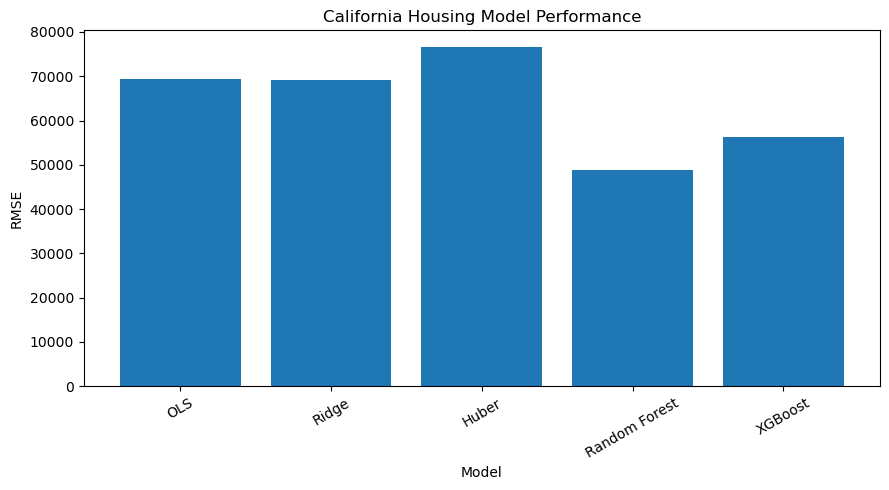

In [25]:
#Plot RMSE
plt.figure(figsize=(9, 5))

plt.bar(
    real_results["Model"],
    real_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("California Housing Model Performance")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../results/figures/real_data_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()